In [3]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [4]:
load_dotenv()
llm = ChatOpenAI()

In [5]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [6]:
def generate_joke(state:JokeState):
    topic = state["topic"]
    prompt = f"generate a joke on the topic {topic}"
    response = llm.invoke(prompt).content
    return {"joke":response}

def generate_explanation(state:JokeState):
    explanation = state["explanation"]
    prompt = f"Write an explanation for the joke -{explanation}"
    response = llm.invoke(prompt)
    return {'explanation':response}

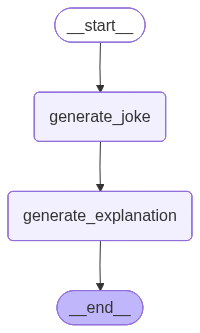

In [7]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)

checkPointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkPointer)
workflow

In [ ]:
config1 = {"configurable":{'thread_id':"1"}}
workflow.invoke({'topic':'pizza'},config=config1)

In [ ]:
workflow.get_state(config1)

In [ ]:
list(workflow.get_state_history(config1))

In [ ]:
config2 = {"configurable":{'thread_id':"2"}}
workflow.invoke({"topic":"pasta"},config=config2)

In [ ]:
workflow.get_state(config2)

In [ ]:
list(workflow.get_state_history(config1))

Time Travel


In [ ]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "Enter the id you want"}})

In [ ]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "Enter the id you want"}})

In [ ]:

list(workflow.get_state_history(config1))

Updating State

In [ ]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "Enter the id you want", "checkpoint_ns": ""}}, {'topic':'samosa'})

In [ ]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "Enter the id you want"}})

In [ ]:

list(workflow.get_state_history(config1))